# SustainGym LLM Curves Generator

Notebook version of `generate_curves_sustaingym.py` 

Agent construction, episode execution (`run_episode`), and plotting all import directly from
`generate_curves_sustaingym.py` / `plot_baseline_comparison_sustaingym.py`

**RUNTIME**: this notebook's kernel must be `sustaingym/.venv_sustaingym`'s Python, not
`EV2Gym/.venv` -- that venv has `sustaingym`, `openai`, `pandas`, and `matplotlib` installed
independently 

## 1. Setup

In [1]:
import os
os.environ["LLM_API_KEY"]  = "Your API Key"
os.environ["LLM_BASE_URL"] = "https://api.groq.com/openai/v1"
os.environ["LLM_MODEL"]    = "llama-3.1-8b-instant"
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def _find_research_root(start: Path) -> Path:
    """Research_Eva/ is the folder with both llm_agents/ and EV2Gym/ as direct
    children. Checked via iterdir() with an exact-case string match, NOT
    Path.exists() -- exists() is case-insensitive on Windows, so a candidate
    of EV2Gym/ itself would falsely satisfy "does a child named EV2Gym exist"
    against its own "ev2gym" package folder (same name, different case).
    Confirmed 2026-07-28: EV2Gym/ also has its own leftover llm_agents/
    folder (stale, from before llm_agents/ was moved to be a sibling of
    EV2Gym/), so with the old exists()-based check EV2Gym/ satisfied BOTH
    conditions and was returned as a false "research root" whenever the
    kernel's cwd started inside EV2Gym/ (e.g. via a workspace/notebook
    default) -- silently misrouting a real 5-seed Groq collection run's
    output CSVs into EV2Gym/llm_agents/curves/ instead of the real
    llm_agents/curves/. iterdir() returns each child's actual on-disk name
    (case preserved), so comparing against the literal "EV2Gym" string is a
    real case-sensitive check even though the filesystem lookup underneath
    it is not. Reused verbatim from ev2gym_curves_generator.ipynb -- this
    notebook's own root-finding needs the exact same fix (its kernel can
    just as easily start inside EV2Gym/), even though generate_curves_sustaingym.py
    itself only needs to find llm_agents/, not EV2Gym/ (see that script's
    module docstring).
    """
    candidate = start
    while True:
        if candidate.exists():
            names = {p.name for p in candidate.iterdir()}
            if "llm_agents" in names and "EV2Gym" in names:
                return candidate
        if candidate == candidate.parent:
            break
        candidate = candidate.parent
    raise FileNotFoundError(
        "Could not find Research_Eva root (a folder containing both 'llm_agents/' "
        f"and 'EV2Gym/'), walking up from {start}."
    )


RESEARCH_ROOT = _find_research_root(Path.cwd())
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

# Importing these pulls in generate_curves_sustaingym.py's own module-level
# bootstrap (RESEARCH_ROOT added to sys.path for `import llm_agents`; no
# EV2Gym/ path entry and no os.chdir -- SustainGym's EVChargingEnv has no
# repo-root-relative config paths, unlike EV2Gym) -- that logic lives there,
# not duplicated here, so the notebook and the CLI script can never drift
# out of sync.
from llm_agents.tests.generate_curves_sustaingym import (
    build_agent,
    run_episode,
    plot_moer_vs_rate,
    plot_profit_vs_carbon,
    plot_satisfaction,
    plot_moer_vs_pilot_scatter,
)

print(f"Research root: {RESEARCH_ROOT}")
print(f"cwd: {Path.cwd()}")

# Groq credentials check -- booleans only, never the key itself.
print()
print("LLM credentials:")
print(f"  LLM_API_KEY  set: {'yes' if os.getenv('LLM_API_KEY') else 'no'}")
print(f"  LLM_BASE_URL set: {'yes' if os.getenv('LLM_BASE_URL') else 'no'} "
      f"(current: {os.getenv('LLM_BASE_URL', '-- unset, defaults to Ollama local --')})")
print(f"  LLM_MODEL    set: {'yes' if os.getenv('LLM_MODEL') else 'no'}")

KeyboardInterrupt: 

## 2. Config

In [ ]:
AGENT = "LLM"  # one of: "LLM", "MaxChargeBaseline", "ZeroChargeBaseline"
                             # set to a free baseline here since that's this notebook's executed/demo run
                             # (free, no API key needed) -- change to "LLM" for the real run.
AGENT_MODE = "coordinated"  # "economic" (single-agent) or "coordinated" (multi-agent).
                          # Only used when AGENT == "LLM" -- ignored for baselines.
SEEDS = [0,1,2,3]  # seed 5 deliberately added beyond the pre-existing 5-seed
                            # MaxChargeBaseline_sustaingym / ZeroChargeBaseline_sustaingym CSVs
                            # already in OUT_DIR -- this confirmation run needs both the
                            # resume-skip path (seeds 0-4) and the incremental-append path
                            # (seed 5) to exercise on the *real* production CSVs, not just a
                            # scratch copy. Trim back to [0, 1, 2, 3, 4] (or expand) for later runs.
MAX_STEPS = 288
SITE = "caltech"
PERIOD = "Summer 2019"
OUT_DIR = "llm_agents/curves"

# Only used when AGENT == "LLM" -- match generate_curves_sustaingym.py's CLI defaults.
LLM_PROVIDER = "groq"
LLM_MODEL = "llama-3.1-8b-instant"
REPLAN_FREQUENCY = 4

OUT_DIR = RESEARCH_ROOT / OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

# RUN_TAG mirrors ev2gym_curves_generator.ipynb's Section 2: distinguishes a
# fresh collection (e.g. after a prompt change) from whatever's already in
# LLM_{AGENT_MODE}_sustaingym_steps.csv. Without this, the resumable run
# cell below would see seeds 0-5 already present and skip every single one
# -- silently doing nothing -- since it has no way to know the *prompt*
# changed underneath it, only that the seed number was already logged.
# Giving a new collection its own filename stem sidesteps that entirely:
# it starts from an empty CSV. Only used when AGENT == "LLM", same as
# AGENT_MODE -- baselines are deterministic and don't need tagging.
RUN_TAG = "postfix3"  # e.g. "moerfix" -- set to "" to target the original (untagged) files

# Filename includes AGENT_MODE (and RUN_TAG, when set) whenever AGENT == "LLM":
# without the AGENT_MODE part, switching AGENT_MODE from "economic" to
# "coordinated" and re-running would resolve to the same LLM_sustaingym_steps.csv
# as before, silently mixing single-agent and multi-agent rows in one file (or
# overwriting one with the other, depending on resume state) since nothing
# else in the filename would have changed. All stems keep
# generate_curves_sustaingym.py's existing "_sustaingym" suffix (its
# collect() already names baseline CSVs "{agent}_sustaingym_steps.csv") --
# this also keeps the LLM's own filenames (e.g.
# LLM_economic_sustaingym_steps.csv) from colliding with the EV2Gym
# notebook's LLM_economic_steps.csv in the same shared llm_agents/curves/
# directory. Baselines don't depend on AGENT_MODE or RUN_TAG at all, so
# their filenames are left exactly as before -- no suffix clutter on those.
if AGENT == "LLM":
    _file_stem = f"LLM_{AGENT_MODE}_sustaingym" + (f"_{RUN_TAG}" if RUN_TAG else "")
else:
    _file_stem = f"{AGENT}_sustaingym"
STEPS_CSV = OUT_DIR / f"{_file_stem}_steps.csv"
DEPARTURES_CSV = OUT_DIR / f"{_file_stem}_departures.csv"
# Per-EVSE-step log (moer_current, pilot_signal, has_slack per active EVSE per
# step) -- new alongside STEPS_CSV/DEPARTURES_CSV, feeds plot_moer_vs_pilot_scatter
# in Section 5. Not produced by older collections, so it starts empty for any
# stem that hasn't been (re)run since this was added -- see run_episode() in
# generate_curves_sustaingym.py.
EVSE_STEPS_CSV = OUT_DIR / f"{_file_stem}_evse_steps.csv"

print(f"Agent          : {AGENT}")
print(f"Agent mode     : {AGENT_MODE if AGENT == 'LLM' else '-- n/a for baselines --'}")
print(f"Run tag        : {RUN_TAG if (AGENT == 'LLM' and RUN_TAG) else '-- none --'}")
print(f"Seeds          : {SEEDS}")
print(f"Max steps      : {MAX_STEPS}")
print(f"Site / period  : {SITE} / {PERIOD}")
print(f"Steps CSV      : {STEPS_CSV}")
print(f"Departures CSV : {DEPARTURES_CSV}")
print(f"EVSE steps CSV : {EVSE_STEPS_CSV}")

Agent          : LLM
Agent mode     : coordinated
Run tag        : postfix3
Seeds          : [0, 1, 2, 3]
Max steps      : 288
Site / period  : caltech / Summer 2019
Steps CSV      : c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_sustaingym_postfix3_steps.csv
Departures CSV : c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_sustaingym_postfix3_departures.csv
EVSE steps CSV : c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_sustaingym_postfix3_evse_steps.csv


## 3. Agent factory

In [ ]:
agent = build_agent(AGENT, llm_provider=LLM_PROVIDER, llm_model=LLM_MODEL, replan_frequency=REPLAN_FREQUENCY, mode=AGENT_MODE)
print(f"Built agent: {AGENT} (mode={AGENT_MODE}) -> {type(agent).__name__}")

Built agent: LLM (mode=coordinated) -> LLMAgentSustainGym


## 4. Run -- incremental save, resumable

Before each seed, checks whether it's already in `{_file_stem}_steps.csv` and skips it if so. Appends
each seed's rows to the CSV immediately after it finishes (not batched at the end of the loop), so
an interrupted run loses at most the seed in progress. Per-seed failures are caught and logged; the
loop continues to the next seed rather than aborting the whole run.

In [ ]:
def _existing_seeds(csv_path: Path) -> set:
    if not csv_path.exists():
        return set()
    try:
        return set(pd.read_csv(csv_path, usecols=["seed"])["seed"].unique().tolist())
    except Exception:
        return set()


def _append_csv(df: pd.DataFrame, csv_path: Path) -> None:
    df.to_csv(csv_path, mode="a", header=not csv_path.exists(), index=False)


done_seeds = _existing_seeds(STEPS_CSV)
if done_seeds:
    print(f"Resuming: seeds already present in {STEPS_CSV.name}: {sorted(done_seeds)}")

n_complete = len(done_seeds)
for seed in SEEDS:
    if seed in done_seeds:
        print(f"seed={seed} already done, skipping")
        continue
    try:
        steps_df, departures_df, evse_steps_df = run_episode(agent, seed, MAX_STEPS, SITE, PERIOD)
        _append_csv(steps_df, STEPS_CSV)
        _append_csv(departures_df, DEPARTURES_CSV)
        _append_csv(evse_steps_df, EVSE_STEPS_CSV)
        n_complete += 1
        print(f"seed={seed} done ({n_complete}/{len(SEEDS)} complete)")
    except Exception as exc:
        print(f"seed={seed} FAILED: {exc}")
        continue

print(f"\nRun complete for this session: {n_complete}/{len(SEEDS)} seeds done.")

Resuming: seeds already present in LLM_coordinated_sustaingym_postfix3_steps.csv: [0, 1, 2]
seed=0 already done, skipping
seed=1 already done, skipping
seed=2 already done, skipping


Failed to parse LLM response as JSON: Failed to parse LLM JSON after 3 repair passes: Expecting ',' delimiter: line 1 column 56 (char 55)
Raw response: {"actions": [{"id": "evse_40", "power_kw": 0.447}, "id": "evse_41", "power_kw": 0.0], "reasoning": "MOER high, shifted 1 EVSE back", "estimated_cost_eur": 0.0}
Failed to parse LLM response as JSON: Failed to parse LLM JSON after 3 repair passes: Expecting ',' delimiter: line 1 column 1959 (char 1958)
Raw response: {"actions": [{"id": "evse_0", "power_kw": 0.0}, {"id": "evse_1", "power_kw": 0.0}, {"id": "evse_2", "power_kw": 0.0}, {"id": "evse_3", "power_kw": 0.0}, {"id": "evse_4", "power_kw": 0.0}, {"id": "evse


seed=3 done (4/4 complete)

Run complete for this session: 4/4 seeds done.


## 5. Plots

Each cell re-reads the CSV from disk (so it reflects whatever's actually been run so far, even
across kernel restarts), saves the PNG the same way `generate_curves_sustaingym.py` does, and
displays it inline.

### MOER vs. charging rate

Saved c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_sustaingym_postfix3_moer_vs_rate.png


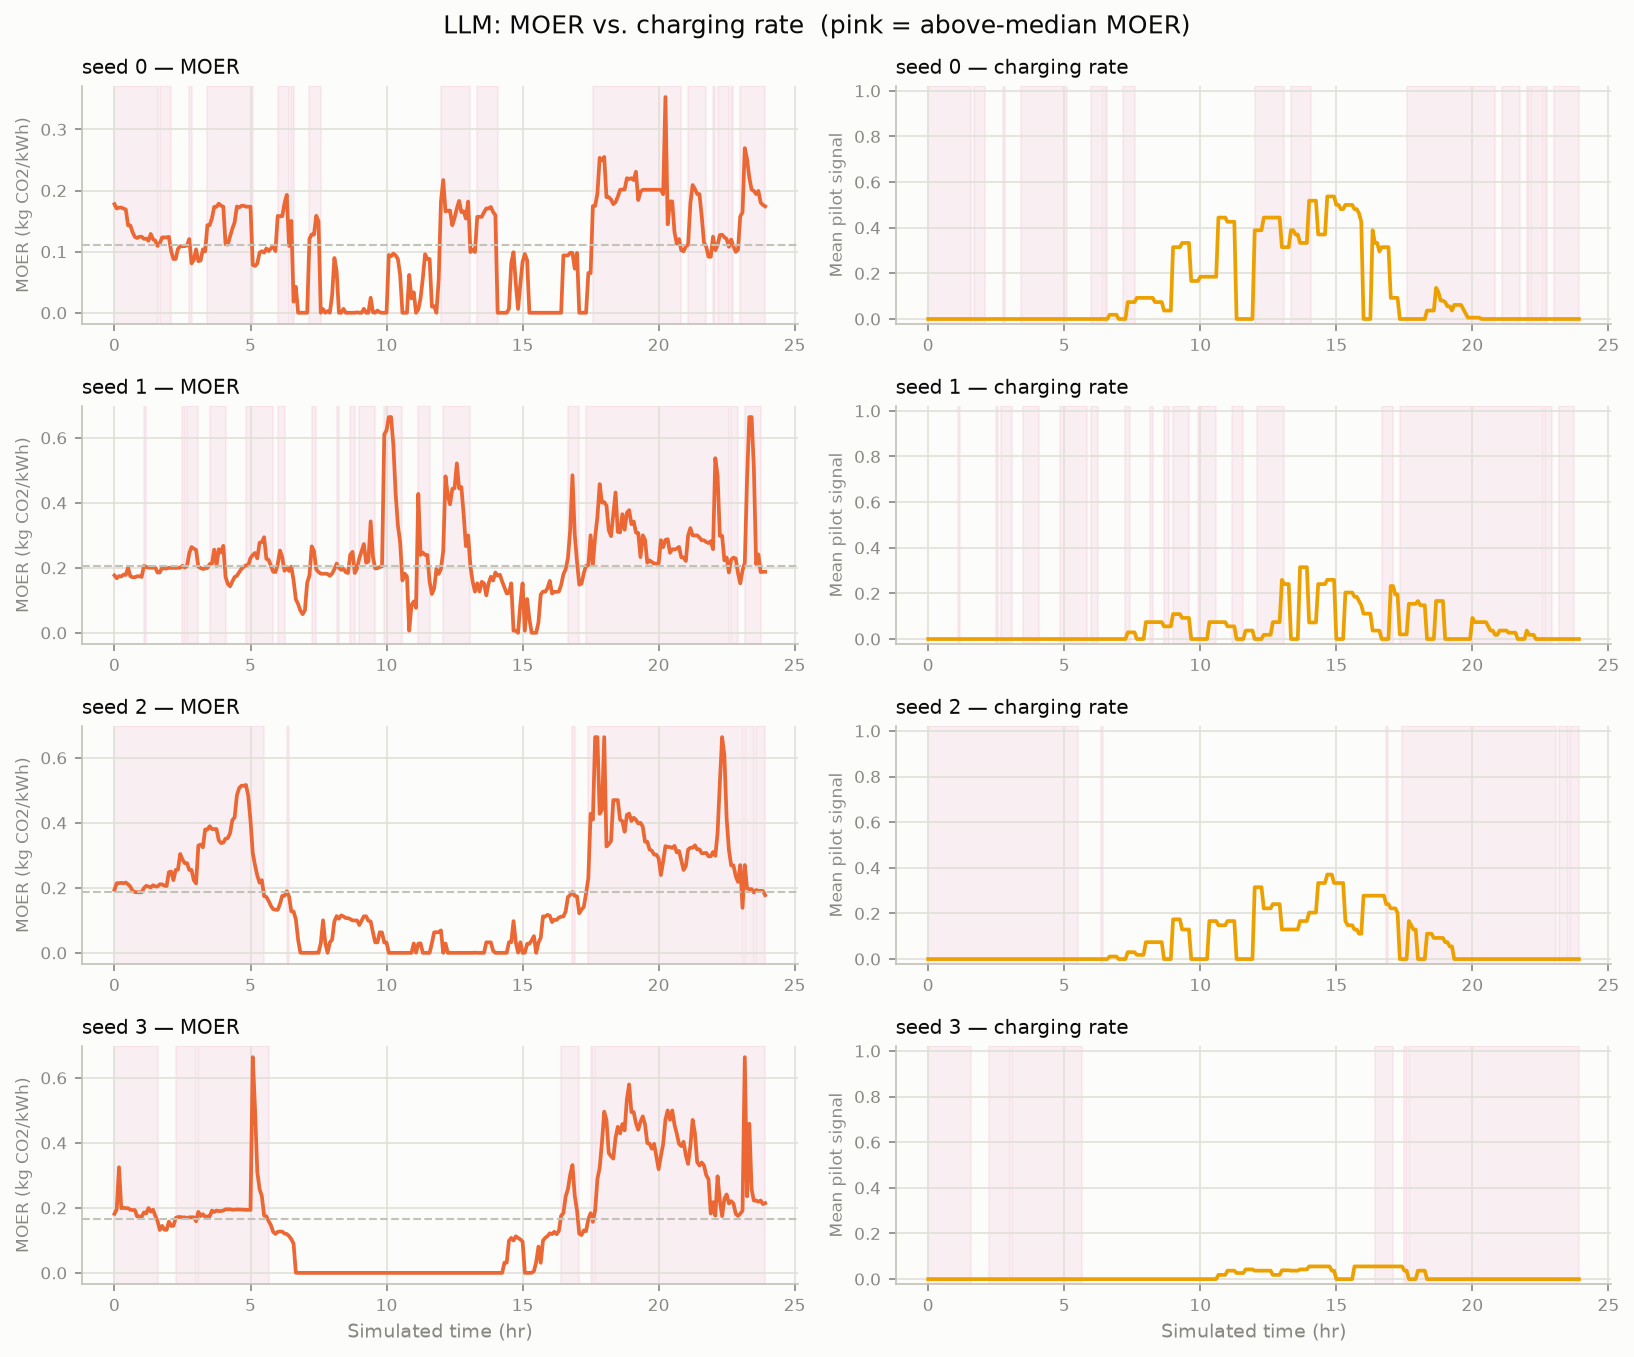

In [ ]:
steps_df = pd.read_csv(STEPS_CSV) if STEPS_CSV.exists() else pd.DataFrame()
n_seeds_present = steps_df["seed"].nunique() if len(steps_df) else 0
if n_seeds_present < len(SEEDS):
    print(f"Note: only {n_seeds_present}/{len(SEEDS)} seeds available -- plotting what exists.")

if len(steps_df):
    out_path = OUT_DIR / f"{_file_stem}_moer_vs_rate.png"
    plot_moer_vs_rate(steps_df, AGENT, out_path)
    display(Image(filename=str(out_path)))
else:
    print("No step data yet -- run the previous cell first.")

### Profit vs. carbon cost trade-off

Saved c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_sustaingym_postfix3_profit_carbon.png


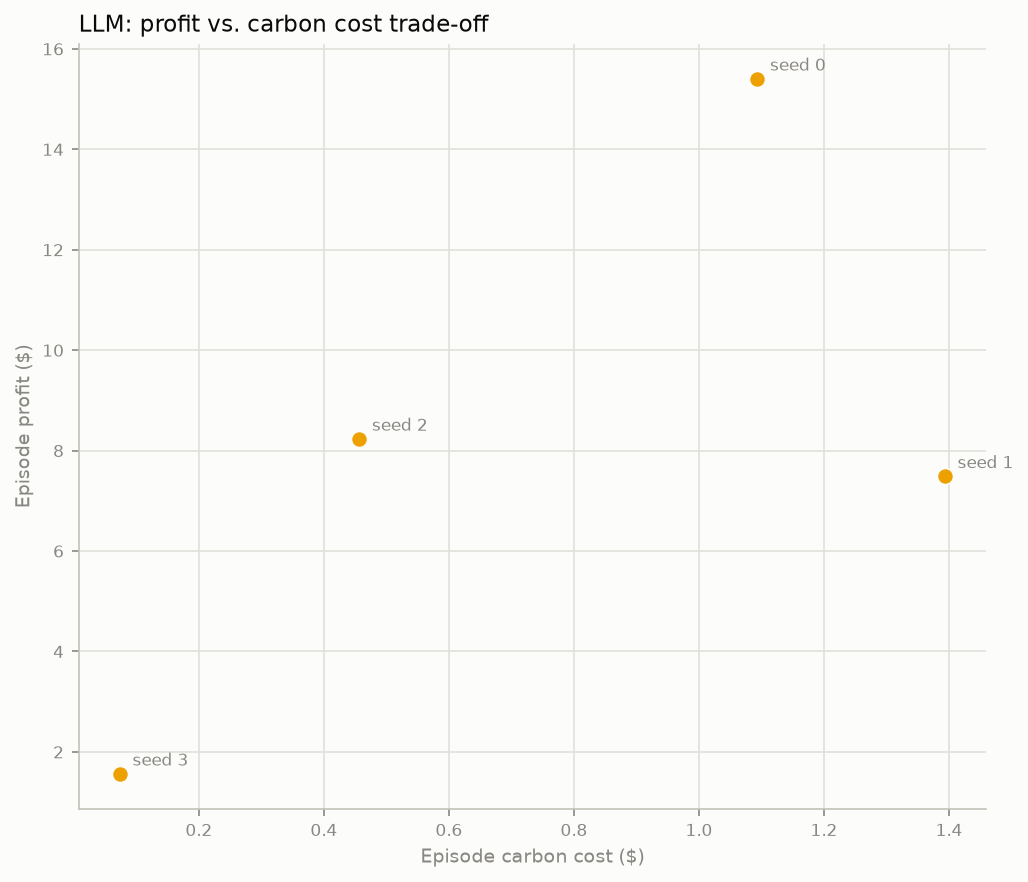

In [ ]:
steps_df = pd.read_csv(STEPS_CSV) if STEPS_CSV.exists() else pd.DataFrame()
n_seeds_present = steps_df["seed"].nunique() if len(steps_df) else 0
if n_seeds_present < len(SEEDS):
    print(f"Note: only {n_seeds_present}/{len(SEEDS)} seeds available -- plotting what exists.")

if len(steps_df):
    out_path = OUT_DIR / f"{_file_stem}_profit_carbon.png"
    plot_profit_vs_carbon(steps_df, AGENT, out_path)
    display(Image(filename=str(out_path)))
else:
    print("No step data yet -- run the previous cell first.")

### Satisfaction at departure

Saved c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_sustaingym_postfix3_satisfaction.png


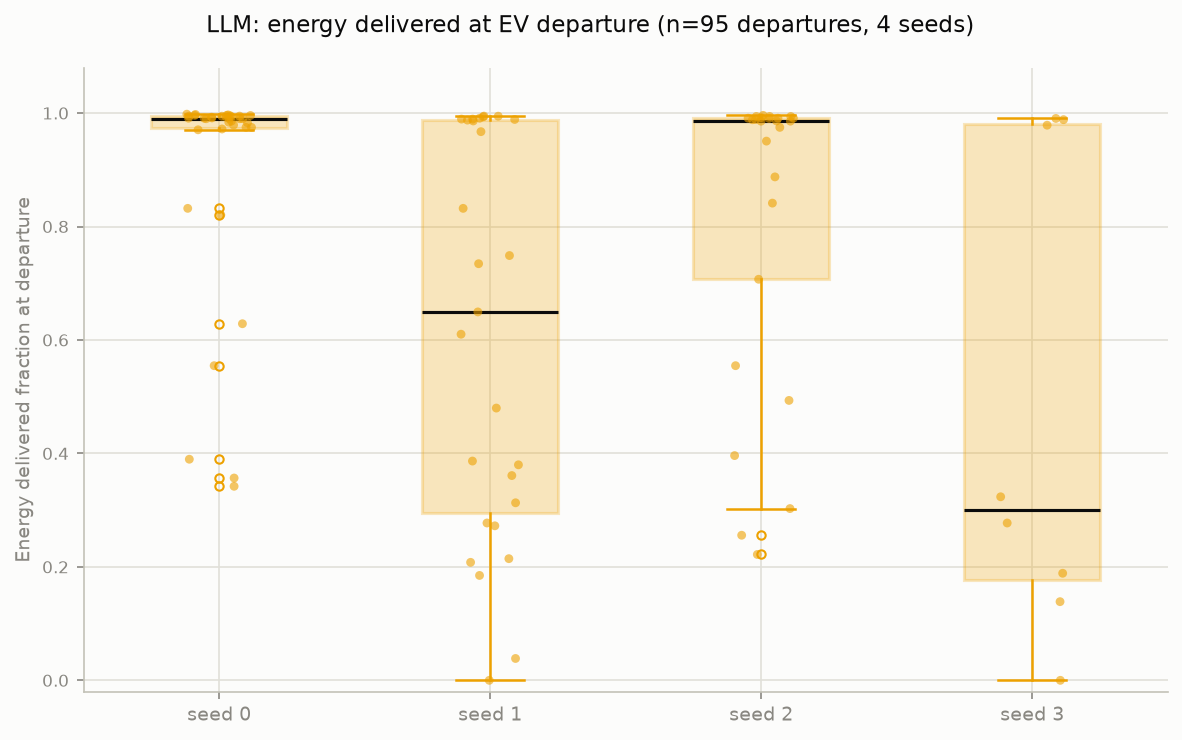

In [ ]:
departures_df = pd.read_csv(DEPARTURES_CSV) if DEPARTURES_CSV.exists() else pd.DataFrame()
n_seeds_present = departures_df["seed"].nunique() if len(departures_df) else 0
if n_seeds_present < len(SEEDS):
    print(f"Note: only {n_seeds_present}/{len(SEEDS)} seeds available -- plotting what exists.")

if len(departures_df):
    out_path = OUT_DIR / f"{_file_stem}_satisfaction.png"
    plot_satisfaction(departures_df, AGENT, out_path)
    display(Image(filename=str(out_path)))
else:
    print("No departures yet -- either the run hasn't happened, or no EV had departed within MAX_STEPS.")

### MOER vs. pilot signal, by urgency

Per-EVSE-step scatter (not the step-level mean used above): each active EVSE at each step is
classified `has_slack` (could still fully deliver its remaining demand later, so the prompt's
CHARGING DEFAULT RULE says it's allowed to throttle below 1.0 on a high-MOER step) or `urgent`
(should stay near 1.0 regardless of MOER). This is the plot that shows whether throttling is
actually concentrated on the EVSEs it's supposed to be, rather than the single pooled
`moer_pilot_correlation` number in `baseline_summary_sustaingym.csv`, which can look the same
whether the response is a real threshold effect or just noise. Requires `EVSE_STEPS_CSV`, which
only exists for collections run since this cell was added (see Section 2).

Saved c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_sustaingym_postfix3_moer_vs_pilot_scatter.png


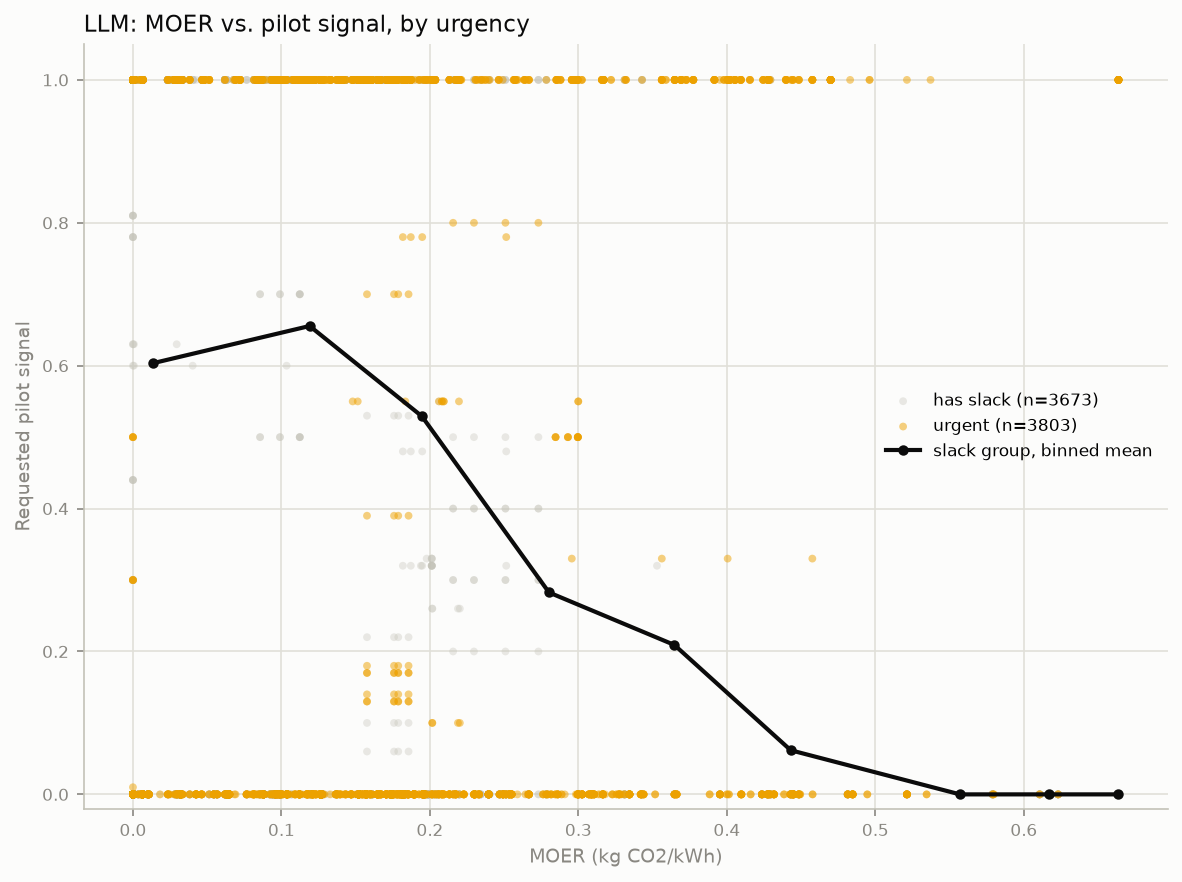

In [ ]:
evse_steps_df = pd.read_csv(EVSE_STEPS_CSV) if EVSE_STEPS_CSV.exists() else pd.DataFrame()
n_seeds_present = evse_steps_df["seed"].nunique() if len(evse_steps_df) else 0
if n_seeds_present < len(SEEDS):
    print(f"Note: only {n_seeds_present}/{len(SEEDS)} seeds available -- plotting what exists.")

if len(evse_steps_df):
    out_path = OUT_DIR / f"{_file_stem}_moer_vs_pilot_scatter.png"
    plot_moer_vs_pilot_scatter(evse_steps_df, AGENT, out_path)
    display(Image(filename=str(out_path)))
else:
    print(f"No EVSE-step data yet in {EVSE_STEPS_CSV.name} -- either the run hasn't happened, "
          "or this stem was collected before this plot was added (rerun Section 4 to backfill).")

## 6. Combined comparison -- all agents

Loads whichever of `{ZeroChargeBaseline, LLM, MaxChargeBaseline}_sustaingym_steps.csv` currently
exist in `OUT_DIR` and builds the same 3-panel `full_comparison_sustaingym.png` /
`baseline_comparison_sustaingym.png` that `plot_baseline_comparison_sustaingym.py` produces from
the command line. Prints which agents are still missing rather than erroring if fewer than 3 are
present.

Saved C:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\baseline_summary_sustaingym_coordinated.csv
             agent  mean_pilot_signal  mean_profit_per_episode  mean_carbon_cost_per_episode  mean_violations_per_episode  mean_net_reward_per_episode  moer_pilot_correlation  mean_satisfaction  parse_failure_rate  satisfaction_above_zerocharge  moer_correlation_vs_llm
ZeroChargeBaseline             0.0000                   0.0000                        0.0000                       0.0000                       0.0000                     NaN             0.0000              0.0000                         0.0000                      NaN
               LLM             0.0627                   8.1705                        0.7544                       0.0003                       7.4158                 -0.2895             0.7635              4.1667                         0.7635                      0.0
 MaxChargeBaseline             1.0000                  10.7285                      

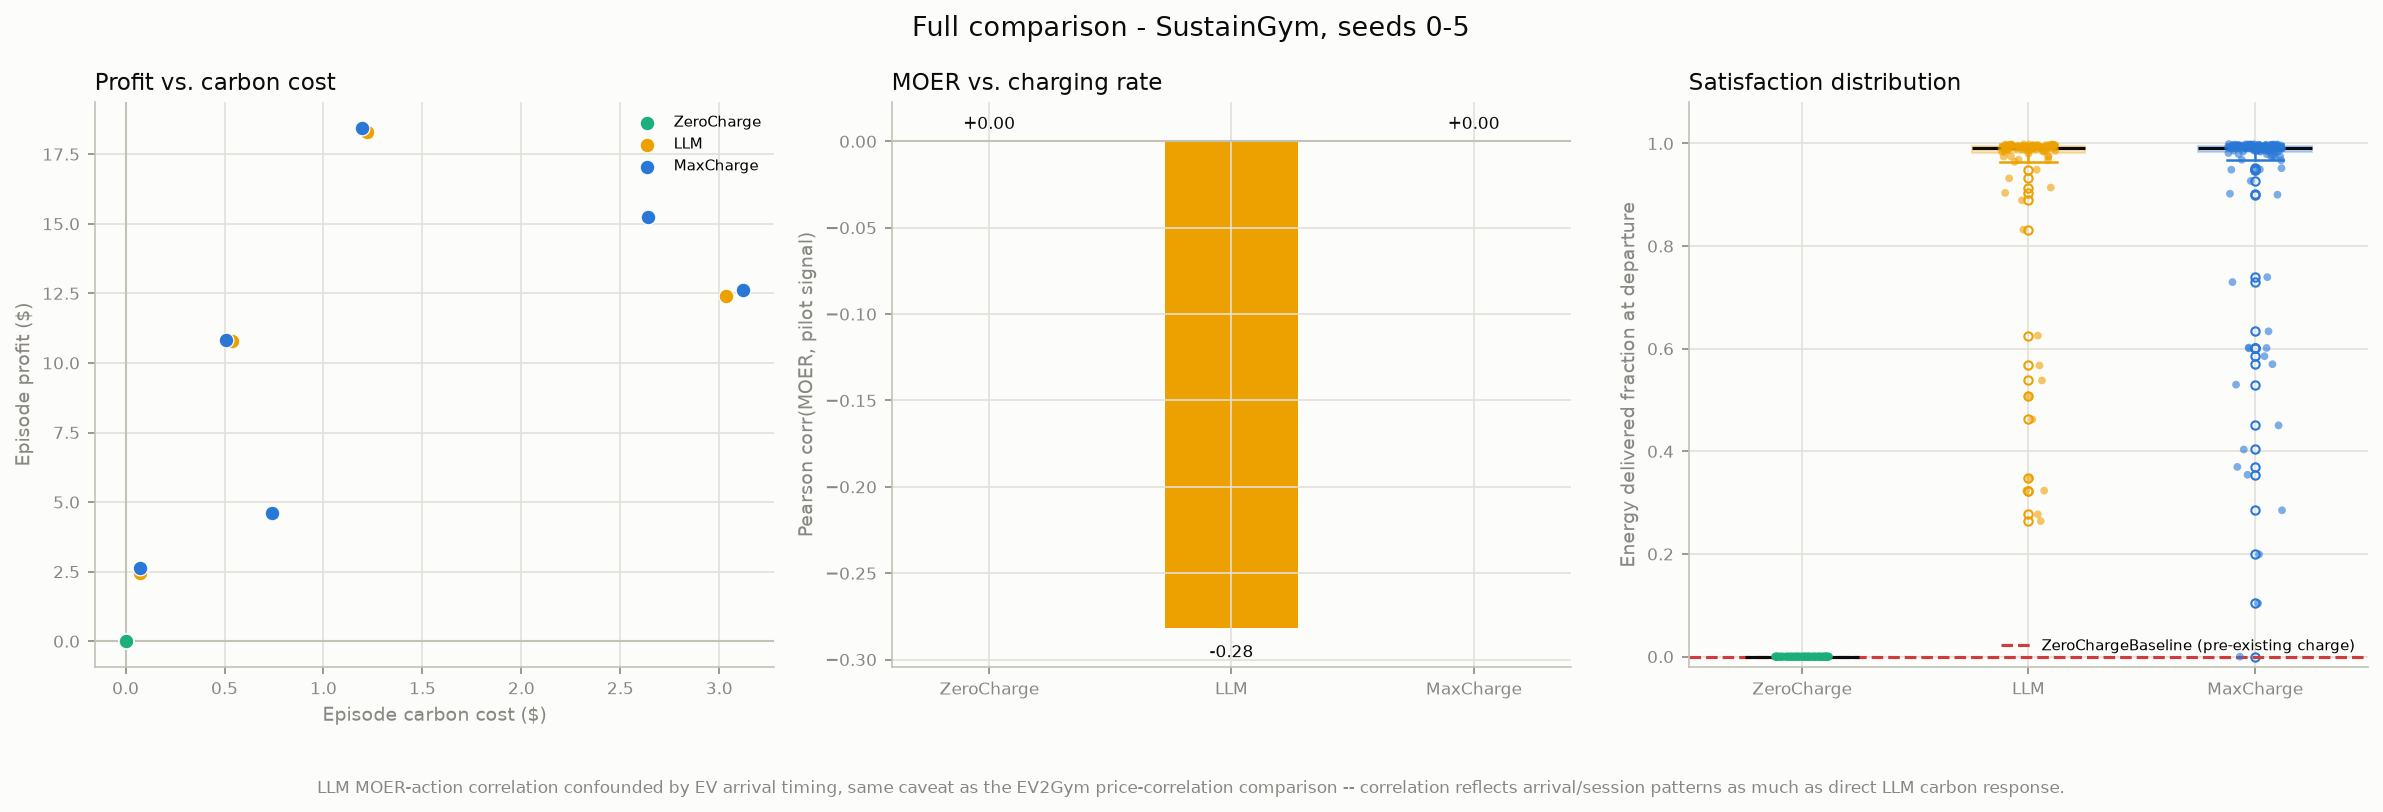

In [ ]:
from llm_agents.tests import plot_baseline_comparison_sustaingym as pbcs

# This notebook names its LLM output by AGENT_MODE + RUN_TAG (see Section 2's
# _file_stem logic), so the combined comparison must look for that same full
# stem -- not the CLI script's fixed "LLM_sustaingym_steps.csv", and not just
# "LLM_{AGENT_MODE}_sustaingym" without RUN_TAG (which would silently read a
# stale/untagged LLM CSV instead of whatever this session's Run cell in
# Section 4 actually just collected). Built explicitly here rather than
# reusing Section 2's _file_stem, since _file_stem tracks whatever AGENT is
# currently set to (which may be a baseline, not "LLM") -- this cell always
# needs the LLM-specific stem regardless of AGENT.
llm_steps_stem = f"LLM_{AGENT_MODE}_sustaingym" + (f"_{RUN_TAG}" if RUN_TAG else "")

try:
    pbcs.main(llm_steps_stem=llm_steps_stem)
    combined_png = pbcs.CURVES_DIR / (
        "full_comparison_sustaingym.png"
        if (pbcs.CURVES_DIR / f"{llm_steps_stem}_steps.csv").exists()
        else "baseline_comparison_sustaingym.png"
    )
    if combined_png.exists():
        display(Image(filename=str(combined_png)))
except FileNotFoundError as exc:
    print(f"Cannot build combined comparison yet: {exc}")

## 7. Thesis summary table

Reads back `baseline_summary_sustaingym{_coordinated}.csv` (just (re)written by Section 6's
`pbcs.main()` call above) and renders it as a table, including `mean_net_reward_per_episode` --
env.step()'s own reward, summed per seed then averaged, so it's the number that actually answers
"did this agent maximize reward" without the reader subtracting profit and carbon cost by hand.
Also prints a Markdown table for pasting directly into the thesis text.

In [ ]:
# Same out_suffix rule as pbcs.main() itself (llm_steps_stem is defined in
# Section 6, above) -- so this reads back exactly the CSV that call just wrote,
# not a stale one from a different AGENT_MODE.
_out_suffix = "_coordinated" if llm_steps_stem.startswith("LLM_coordinated") else ""
_summary_path = pbcs.CURVES_DIR / f"baseline_summary_sustaingym{_out_suffix}.csv"

if _summary_path.exists():
    summary_df = pd.read_csv(_summary_path, comment="#")
    display(summary_df)

    print("\nMarkdown (paste directly into thesis text):\n")
    try:
        print(summary_df.to_markdown(index=False))
    except ImportError:
        # to_markdown() needs the optional `tabulate` package -- fall back to
        # a plain aligned table rather than erroring the whole cell out.
        print("(install `tabulate` for Markdown output; showing plain table instead)\n")
        print(summary_df.to_string(index=False))
else:
    print(f"No summary CSV yet at {_summary_path} -- run Section 6's cell first.")


,agent,mean_pilot_signal,mean_profit_per_episode,mean_carbon_cost_per_episode,mean_violations_per_episode,mean_net_reward_per_episode,moer_pilot_correlation,mean_satisfaction,parse_failure_rate,satisfaction_above_zerocharge,moer_correlation_vs_llm
0,ZeroChargeBaseline,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,NaN
1,LLM,0.0627,8.1705,0.7544,0.0003,7.4158,-0.2895,0.7635,4.1667,0.7635,0.0
2,MaxChargeBaseline,1.0000,10.7285,1.3801,0.0001,9.3483,NaN,0.9240,0.0000,0.9240,NaN



Markdown (paste directly into thesis text):

(install `tabulate` for Markdown output; showing plain table instead)

             agent  mean_pilot_signal  mean_profit_per_episode  mean_carbon_cost_per_episode  mean_violations_per_episode  mean_net_reward_per_episode  moer_pilot_correlation  mean_satisfaction  parse_failure_rate  satisfaction_above_zerocharge  moer_correlation_vs_llm
ZeroChargeBaseline             0.0000                   0.0000                        0.0000                       0.0000                       0.0000                     NaN             0.0000              0.0000                         0.0000                      NaN
               LLM             0.0627                   8.1705                        0.7544                       0.0003                       7.4158                 -0.2895             0.7635              4.1667                         0.7635                      0.0
 MaxChargeBaseline             1.0000                  10.7285           